## 2 excitatory, 1 inhibitory neuron

#### Scheme:

    3 coupled neurons, 2 N_E and N_I
    Different inputs (static currents or sinusoids)
    Both have an autapse of varying strength
    The idea is to produce either winner-takes-all-dynamics or coherence.
    We can cut out some synapses in order to simulate different 2 neuron circuits...

#### Question:

    Can N_E control the output frequency of N_I?
    Can N_I control the output frequency of N_E?
    Does the autapse play a role in this?
    
#### Parameters to vary:

    Respective inputs I1/I2, which neuron fires more?
    synapse strengths: Which neuron holds more influence?
    autapse strength: Can the behaviour change as the autapse is strengthened?

#### Metrics:

    -> compare to uncoupled system
    -> van Rossum distance? do the neurons synchronise better?
    -> Which neuron entrains which? Is there a way to show which neuron adapts more? 

In [9]:

''' import aqua '''
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA

'''general imports''' 
import numpy as np
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
I_neuron = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0., 'f': 0., 'tau': 0.}

# strong autaptic neuron on RS integrator...
E1_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 2.}

# non-autaptic neuron - RS integrator
E2_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

def visualise_connectivity(S):
    Ns = len(S.source)
    Nt = len(S.target)
    figure(figsize=(10, 4))
    subplot(121)
    plot(zeros(Ns), arange(Ns), 'ok', ms=10)
    plot(ones(Nt), arange(Nt), 'ok', ms=10)
    for i, j in zip(S.i, S.j):
        plot([0, 1], [i, j], '-k')
    xticks([0, 1], ['Source', 'Target'])
    ylabel('Neuron index')
    xlim(-0.1, 1.1)
    ylim(-1, max(Ns, Nt))
    subplot(122)
    plot(S.i, S.j, 'ok')
    xlim(-1, Ns)
    ylim(-1, Nt)
    xlabel('Source neuron index')
    ylabel('Target neuron index')

In [11]:
start_scope()

# simulation parameters
T = 5000 # ms
dt = 0.1
N_iter = int(T/dt)

''' - - - define the excitatory population - - - '''
# neuron parameters
params_E = [E1_neuron, E2_neuron]      # 2 neurons

x_start = np.full(shape = (2, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(2)

# create the batch
batch_E = batchAQUA(params_E)
batch_E.Initialise(x_start, t_start)

# create the input current - STEP CURRENT
I_h1 = 75
I1 = I_h1 * np.ones(N_iter)         # stronger driving current to E1s
I_h2 = 75
I2 = I_h2 * np.ones(N_iter)         # weaker current to E2

I_inj = np.array([I1, I2])
I_excTA = TimedArray(values = I_inj.T, dt = dt*ms, name = 'I_excTA')

# convert to brian2 with the standard autapse model
E, aut_E = batch_E.meetBrian(stimulus_name = I_excTA)

''' - - - define the inhibitory neuron - - - '''
param_I = [I_neuron]
x_start = np.array([[-60, 0, 0]])
t_start = np.array([0.])

# create batch 
batch_I = batchAQUA(param_I)
batch_I.Initialise(x_start, t_start)

# input current will be just subthreshold
threshold, _ = batch_I.get_threshold(idx = 0)
threshold += 1
I_inh = np.array([threshold*np.ones(N_iter)])
print(np.shape(I_inh))
I_inhTA = TimedArray(values = I_inh.T, dt = dt*ms, name = 'I_inhTA')

# create brian objects, no effective autapse here.
I, aut_I = batch_I.meetBrian(stimulus_name = I_inhTA)


''' - - - create the synapses - - - '''
# create the synapses between E1 and E2...
# I_sun represents the synapse strength
syn_eq = """
dI_syn/dt = -(I_syn/t_syn)/ms : 1 (clock-driven)
t_syn : 1
w_syn : 1
g_total_syn = I_syn : 1 

"""
syn_on_pre = '''I_syn += w_syn'''

'''exc. synapses'''
# fully connect excitatory neurons (ignoring autapses)
syn_E = Synapses(E, E, 
                model = syn_eq,
                on_pre = syn_on_pre,
                method = 'rk2')
syn_E.connect(condition = 'i != j')     # fully connected minus autapses

## Set exc. synapse variables here...
syn_E.I_syn = 0.
syn_E.t_syn = 5   # ms
syn_E.w_syn[0, 1] = 0   #pA, weight from E1 -> E2
syn_E.w_syn[1, 0] = 0   #pA, weight from E2 -> E1

'''inh. to exc. synapses'''
syn_IE = Synapses(I, E,
                model = syn_eq,
                on_pre = syn_on_pre,
                method = 'rk2')
syn_IE.connect()         # fully connected to the 2 exc. neurons

## set inh. synapse variables
syn_IE.I_syn = 0.         # initially no current through the synapse
syn_IE.t_syn = 5          # ms
syn_IE.w_syn[0, 0] = -75   #pA, weight from I -> E1
syn_IE.w_syn[0, 1] = -75   #pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

'''exc. to inh. synapses'''
syn_EI = Synapses(E, I,
                model = syn_eq,
                on_pre = syn_on_pre,
                method = 'rk2')
syn_EI.connect()         # both excitatory neurons connect to I

## set inh. synapse variables
syn_EI.I_syn = 0.         # initially no current through the synapse
syn_EI.t_syn = 5          # ms
syn_EI.w_syn[0, 0] = 0   #pA, weight from I -> E1
syn_EI.w_syn[1, 0] = 0   #pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

''' - - simulation - - '''
# set simulation parameters
defaultclock.dt = dt*ms
# Monitors
M_v_E = StateMonitor(E, 'v', record = True)
M_v_I = StateMonitor(I, 'v', record = True)
spikemon_E = SpikeMonitor(E, record = True)
spikemon_I = SpikeMonitor(I, record = True)
M_syn_E = StateMonitor(syn_E, 'I_syn', record = True)   # record the current through the synapse
M_syn_IE = StateMonitor(syn_IE, 'I_syn', record = True)   
M_syn_EI = StateMonitor(syn_EI, 'I_syn', record = True)   

# create networks
net = Network(E, I, aut_E, aut_I, syn_E, syn_IE, syn_EI, M_v_E, M_v_I, spikemon_E, spikemon_I, M_syn_E, M_syn_IE, M_syn_EI)

net.run(T*ms)

spike_trains_E = spikemon_E.spike_trains()
spike_trains_I = spikemon_I.spike_trains()


WARNING    The object 'synapses_5' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File 'C:\Users\liamm\Documents\PhD_autapses\Programming_files\AQUA_package\aqua\batchAQUA_general.py', line 303, in meetBrian
    autapses = Synapses(G, G, on_pre = syn_reset) [brian2.core.base.unused_brian_object]


- - threshold - -


100%|██████████| 59999/59999 [00:09<00:00, 6521.86it/s]


(1, 50000)
ALL FS!!!


WARNING    The object 'neurongroup_2' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File 'C:\Users\liamm\Documents\PhD_autapses\Programming_files\AQUA_package\aqua\batchAQUA_general.py', line 294, in meetBrian
    G = NeuronGroup(self.N_models, EQS, threshold = 'v >= v_peak', reset = RESET, method = 'rk2', namespace = {'stimulus': stimulus_name}) [brian2.core.base.unused_brian_object]
WARNING    'dt' is an internal variable of group 'synapses_7', but also exists in the run namespace with the value 0.1. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'dt' is an internal variable of group 'synapses_8', but also exists in the run namespace with the value 0.1. The internal variable will be used. [brian2.groups.group.Group.resolve.reso

Text(0.5, 47.7222222222222, 'Time [ms]')

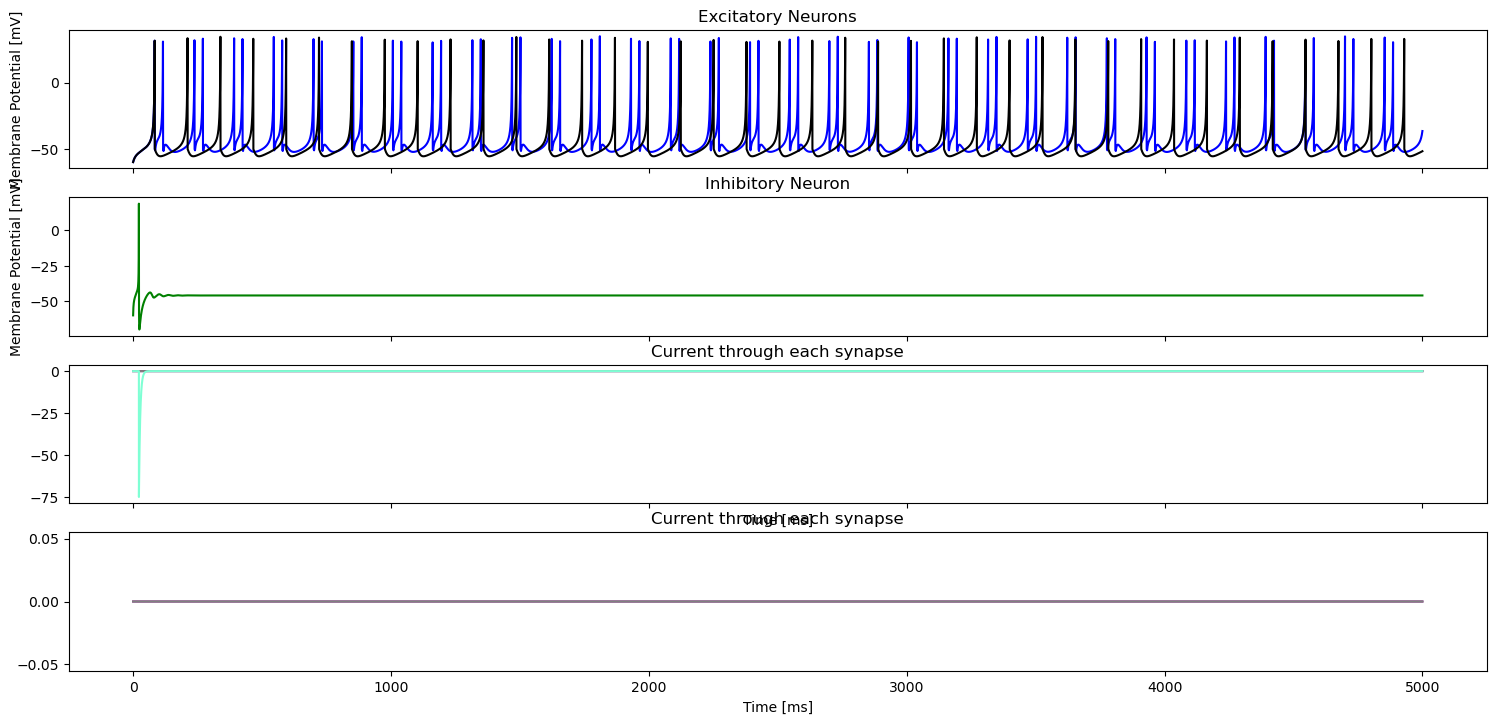

In [12]:
### Plot the outputs
# Need some systematic way of analysing the outputs

fig, ax = plt.subplots(4, 1, figsize = (15, 7), sharex = True)
fig.tight_layout()

ax[0].plot(M_v_E.t/ms, M_v_E.v[0], c = 'blue', label = 'autaptic neuron')
ax[0].plot(M_v_E.t/ms, M_v_E.v[1], c = 'black', label = 'non-autaptic neuron')
ax[0].set_title('Excitatory Neurons')
ax[0].set_ylabel('Membrane Potential [mV]')

ax[1].plot(M_v_I.t/ms, M_v_I.v[0], c = 'green', label = 'inhibitory neuron')
ax[1].set_title('Inhibitory Neuron')
ax[1].set_ylabel('Membrane Potential [mV]')

ax[2].plot(M_syn_E.t/ms, M_syn_E.I_syn[0], c = 'purple', label = 'E1 -> E2')
ax[2].plot(M_syn_E.t/ms, M_syn_E.I_syn[1], c = 'gray', label = 'E2 -> E1')
ax[2].plot(M_syn_IE.t/ms, M_syn_IE.I_syn[0], c = 'aquamarine', label = 'I -> E1/E2')
ax[2].set_title('Current through each synapse')
ax[2].set_xlabel('Time [ms]')

ax[3].plot(M_syn_EI.t/ms, M_syn_EI.I_syn[0], c = 'purple', label = 'E1 -> I')
ax[3].plot(M_syn_EI.t/ms, M_syn_EI.I_syn[1], c = 'gray', label = 'E2 -> I')
ax[3].set_title('Current through each synapse')
ax[3].set_xlabel('Time [ms]')


In [13]:
start_scope()

# simulation parameters
T = 5000 # ms
dt = 0.1
N_iter = int(T/dt)

''' - - - define the excitatory population - - - '''
# neuron parameters
params_E = [E1_neuron, E2_neuron]      # 2 neurons

x_start = np.full(shape = (2, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(2)

# create the batch
batch_E = batchAQUA(params_E)
batch_E.Initialise(x_start, t_start)

# create the input current - STEP CURRENT
I_h1 = 75
I1 = I_h1 * np.ones(N_iter)         # stronger driving current to E1s
I_h2 = 75
I2 = I_h2 * np.ones(N_iter)         # weaker current to E2

I_inj = np.array([I1, I2])
I_excTA = TimedArray(values = I_inj.T, dt = dt*ms, name = 'I_excTA')

# convert to brian2 with the standard autapse model
E, aut_E = batch_E.meetBrian(stimulus_name = I_excTA)

''' - - - define the inhibitory neuron - - - '''
param_I = [I_neuron]
x_start = np.array([[-60, 0, 0]])
t_start = np.array([0.])

# create batch 
batch_I = batchAQUA(param_I)
batch_I.Initialise(x_start, t_start)

# input current will be just subthreshold
threshold, _ = batch_I.get_threshold(idx = 0)
threshold += 1
I_inh = np.array([threshold*np.ones(N_iter)])
print(np.shape(I_inh))
I_inhTA = TimedArray(values = I_inh.T, dt = dt*ms, name = 'I_inhTA')

# create brian objects, no effective autapse here.
I, aut_I = batch_I.meetBrian(stimulus_name = I_inhTA)


''' - - - create the synapses - - - '''
# create the synapses between E1 and E2...
# I_sun represents the synapse strength
syn_eq = """
dI_syn/dt = -(I_syn/t_syn)/ms : 1 (clock-driven)
t_syn : 1
w_syn : 1
g_total_syn = I_syn : 1 

"""
syn_on_pre = '''I_syn += w_syn'''

'''exc. synapses'''
# fully connect excitatory neurons (ignoring autapses)
syn_E = Synapses(E, E, 
                model = syn_eq,
                on_pre = syn_on_pre,
                method = 'rk2')
syn_E.connect(condition = 'i != j')     # fully connected minus autapses

## Set exc. synapse variables here...
syn_E.I_syn = 0.
syn_E.t_syn = 5   # ms
syn_E.w_syn[0, 1] = 50   #pA, weight from E1 -> E2
syn_E.w_syn[1, 0] = 50   #pA, weight from E2 -> E1

'''inh. to exc. synapses'''
syn_IE = Synapses(I, E,
                model = syn_eq,
                on_pre = syn_on_pre,
                method = 'rk2')
syn_IE.connect()         # fully connected to the 2 exc. neurons

## set inh. synapse variables
syn_IE.I_syn = 0.         # initially no current through the synapse
syn_IE.t_syn = 5          # ms
syn_IE.w_syn[0, 0] = -75   #pA, weight from I -> E1
syn_IE.w_syn[0, 1] = -75   #pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

'''exc. to inh. synapses'''
syn_EI = Synapses(E, I,
                model = syn_eq,
                on_pre = syn_on_pre,
                method = 'rk2')
syn_EI.connect()         # both excitatory neurons connect to I

## set inh. synapse variables
syn_EI.I_syn = 0.         # initially no current through the synapse
syn_EI.t_syn = 5          # ms
syn_EI.w_syn[0, 0] = 100   #pA, weight from I -> E1
syn_EI.w_syn[1, 0] = 100   #pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

''' - - simulation - - '''
# set simulation parameters
defaultclock.dt = dt*ms
# Monitors
M_v_E = StateMonitor(E, 'v', record = True)
M_v_I = StateMonitor(I, 'v', record = True)
spikemon_E = SpikeMonitor(E, record = True)
spikemon_I = SpikeMonitor(I, record = True)
M_syn_E = StateMonitor(syn_E, 'I_syn', record = True)   # record the current through the synapse
M_syn_IE = StateMonitor(syn_IE, 'I_syn', record = True)   
M_syn_EI = StateMonitor(syn_EI, 'I_syn', record = True)   

# create networks
net = Network(E, I, aut_E, aut_I, syn_E, syn_IE, syn_EI, M_v_E, M_v_I, spikemon_E, spikemon_I, M_syn_E, M_syn_IE, M_syn_EI)

net.run(T*ms)

spike_trains_E = spikemon_E.spike_trains()
spike_trains_I = spikemon_I.spike_trains()

- - threshold - -


100%|██████████| 59999/59999 [00:11<00:00, 5289.83it/s]


(1, 50000)
ALL FS!!!


Text(0.5, 47.7222222222222, 'Time [ms]')

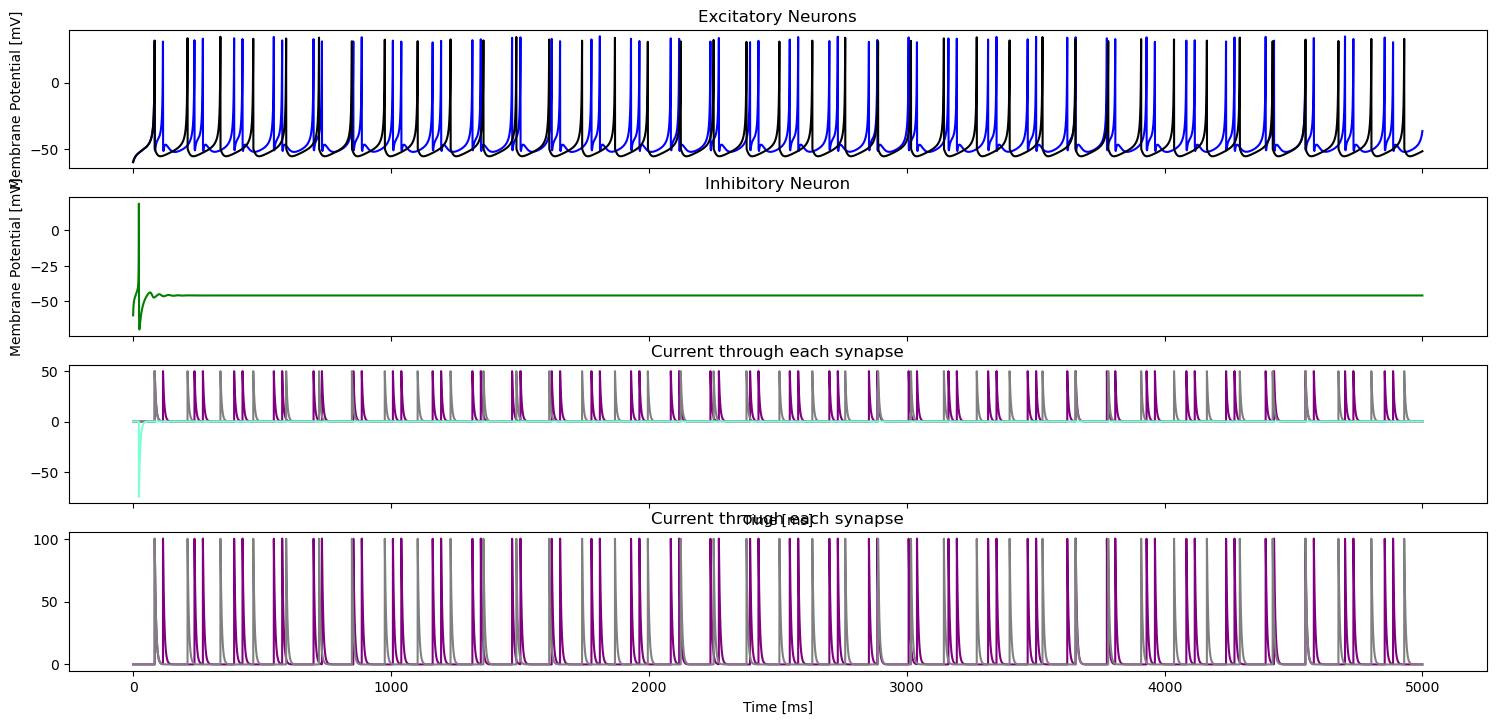

In [14]:
### Plot the outputs
# Need some systematic way of analysing the outputs

fig, ax = plt.subplots(4, 1, figsize = (15, 7), sharex = True)
fig.tight_layout()

ax[0].plot(M_v_E.t/ms, M_v_E.v[0], c = 'blue', label = 'autaptic neuron')
ax[0].plot(M_v_E.t/ms, M_v_E.v[1], c = 'black', label = 'non-autaptic neuron')
ax[0].set_title('Excitatory Neurons')
ax[0].set_ylabel('Membrane Potential [mV]')

ax[1].plot(M_v_I.t/ms, M_v_I.v[0], c = 'green', label = 'inhibitory neuron')
ax[1].set_title('Inhibitory Neuron')
ax[1].set_ylabel('Membrane Potential [mV]')

ax[2].plot(M_syn_E.t/ms, M_syn_E.I_syn[0], c = 'purple', label = 'E1 -> E2')
ax[2].plot(M_syn_E.t/ms, M_syn_E.I_syn[1], c = 'gray', label = 'E2 -> E1')
ax[2].plot(M_syn_IE.t/ms, M_syn_IE.I_syn[0], c = 'aquamarine', label = 'I -> E1/E2')
ax[2].set_title('Current through each synapse')
ax[2].set_xlabel('Time [ms]')

ax[3].plot(M_syn_EI.t/ms, M_syn_EI.I_syn[0], c = 'purple', label = 'E1 -> I')
ax[3].plot(M_syn_EI.t/ms, M_syn_EI.I_syn[1], c = 'gray', label = 'E2 -> I')
ax[3].set_title('Current through each synapse')
ax[3].set_xlabel('Time [ms]')